## Desafio Formacion de Estrellas

En este desafio, debemos resolver numericamente una modelacion matematica de un sistema de formacion de estrellas.

Un simple modelo de formacion de estrellas se puede escribir asi: <br>

$$  a + m + s = 1 $$

Si a es la fracción de masa de gas atómico, m la fracción de masa de
gas molecular y s la fracción de masa de estrellas activas..

donde 1 es la masa total considerada, y para ciertas constantes $k_1 > 0$ , $k_2 > 0$ y  $\alpha > 1$ se tiene

$$ \frac{da}{dt} = s - k_1 m^2 a $$

$$ \frac{dm}{dt} = k_1 m^2 a - k_2 m^\alpha s $$

donde t se mide en millones de años y definiremos un intervalo de $[0, T]$ con $T = 100$ (millones de años) y un paso de tiempo de $\Delta t = 0.1$.

### Inicio de la actividad

1. Resuelva numéricamente el sistema usando el método de Euler para obtener la evolución de la masa de estrellas s para una fracción inicial de gas atómico y molecular de a(0) y m(0) en los distintos 6 casos del diccionario entregado. Grafique superpuestas las tres curvas de a, m y s en cada caso etiquetando las curvas. Si en alguno de los casos el método de Euler diverge, esto es, si obtiene valores muy grandes fuera del rango $[0, 1]$, disminuya el paso de tiempo $\Delta t$ hasta obtener convergencia y repórtelo.

Consideremos los parametros:

In [90]:
import numpy as np
import matplotlib.pyplot as plt

params = { "k1" : [10, 8, 8, 8, 8, 8], \
           "k2" : [10, 15, 15, 15, 15, 15], \
           "alpha": [1.0, 1.2, 1.5, 1.9, 2.0, 2.1], \
           "a0": [0.15, 0.4, 0.4, 0.4, 0.4, 0.4], \
           "m0": [0.15, 0.3, 0.3, 0.3, 0.3, 0.3] }

Y las funciones del sistema:

In [91]:
def objFunc(t, y, k1, k2, alpha):
    a, m = y
    s = 1 - a - m
    
    # The ODEs
    dadt = s - k1 * (m**2) * a
    dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s
    
    return [dadt, dmdt]

T = 100
dt = 0.1
t0 = 0
t = np.linspace(0, 100, int(T/dt) + 1)

cases = [
    {"a0": params["a0"][0], "m0": params["m0"][0], "k1": params["k1"][0], "k2": params["k2"][0], "alpha": params["alpha"][0]},
    {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": params["alpha"][1]},
    {"a0": params["a0"][2], "m0": params["m0"][2], "k1": params["k1"][2], "k2": params["k2"][2], "alpha": params["alpha"][2]},
    {"a0": params["a0"][3], "m0": params["m0"][3], "k1": params["k1"][3], "k2": params["k2"][3], "alpha": params["alpha"][3]},
    {"a0": params["a0"][4], "m0": params["m0"][4], "k1": params["k1"][4], "k2": params["k2"][4], "alpha": params["alpha"][4]},
    {"a0": params["a0"][5], "m0": params["m0"][5], "k1": params["k1"][5], "k2": params["k2"][5], "alpha": params["alpha"][5]}
]


def solveEuler(fun, t0, T, y0, dt, args=()):
    tVal = np.arange(t0, T + dt, dt)
    yVal = np.zeros((len(tVal), len(y0)))
    yVal[0] = y0

    for i in range(1, len(tVal)): # metodo euler
        slope = np.array(fun(tVal[i-1], yVal[i-1], *args))
        yVal[i] = yVal[i-1] + dt * slope

    return {
        't': tVal, 
        'y': yVal.T  # Index 0 = a, Index 1 = m
    }


results = []

T = 100
dt = 0.05

for case in cases: # itera por todas las opciones de casos
    y0 = [case["a0"], case["m0"]]
    args = (case["k1"], case["k2"], case["alpha"])
    res = solveEuler(objFunc, 0, T, y0, dt, args=args)
    results.append(res)


C:\Users\Seba RC\AppData\Local\Temp\ipykernel_14236\3273882896.py:7: RuntimeWarning: invalid value encountered in scalar power
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s


Con esto, tenemos todos los casos posibles en los resultados. Probemos graficar a uno:

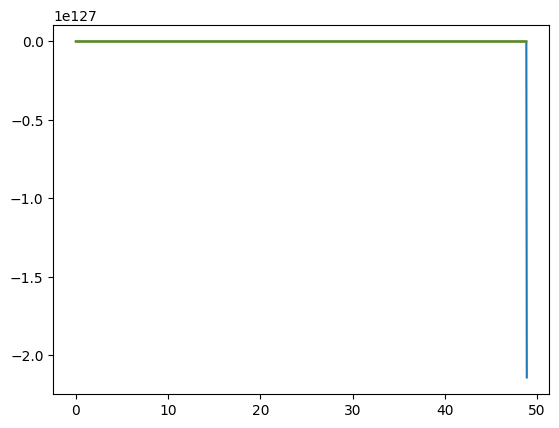

In [92]:
tTest = results[1]['t']
aTest = results[1]['y'][0]
mTest = results[1]['y'][1]
sTest = 1 - aTest - mTest 
plt.plot(tTest, aTest, label='a')
plt.plot(tTest, mTest, label='m')
plt.plot(tTest, sTest, label='s')
plt.show()

En este caso, diverge. Probaremos aislar el caso para poder facilmente cambiar los parametros.

C:\Users\Seba RC\AppData\Local\Temp\ipykernel_14236\3273882896.py:7: RuntimeWarning: invalid value encountered in scalar power
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s


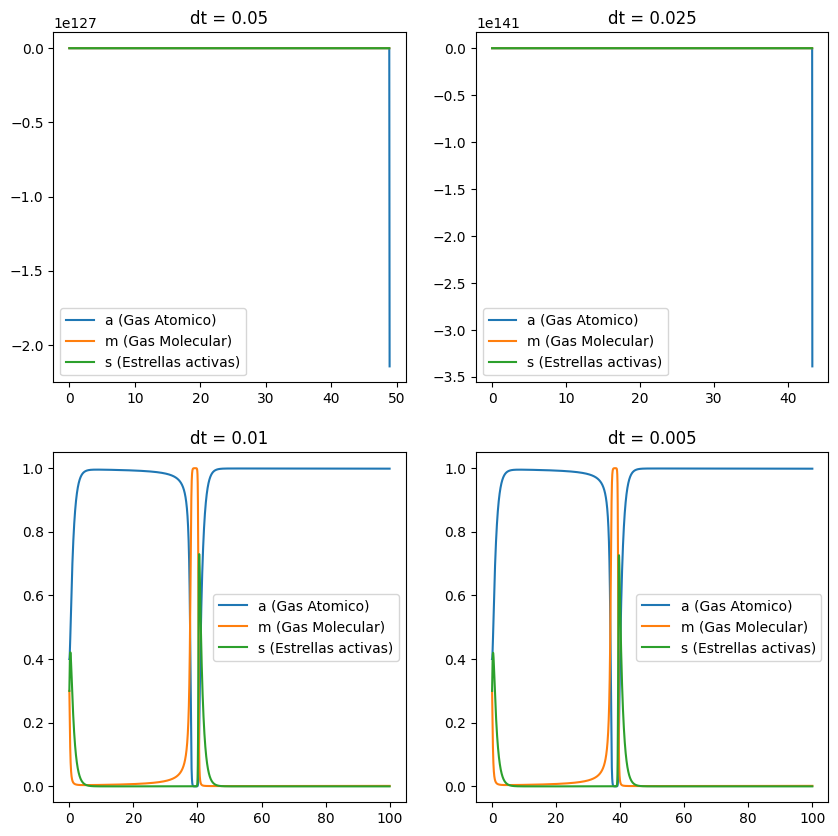

In [93]:
testParams = {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": params["alpha"][1]}

y0 = [testParams["a0"], testParams["m0"]]
args = (testParams["k1"], testParams["k2"], testParams["alpha"]) 
# Probemos lentamente bajar el dt. Intentemos con diferentes valores de dt.
dtCases = [0.05, 0.025, 0.01, 0.005]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i in range(len(dtCases)):
    res = solveEuler(objFunc, 0, T, y0, dtCases[i], args=args)
    aTest = res['y'][0]
    mTest = res['y'][1]
    sTest = 1 - aTest - mTest

    axes[i].plot(res['t'], aTest, label='a (Gas Atomico)')
    axes[i].plot(res['t'], mTest, label='m (Gas Molecular)')
    axes[i].plot(res['t'], sTest, label='s (Estrellas activas)')
    axes[i].set_title(f"dt = {dtCases[i]}")
    axes[i].legend()


plt.show()


Bueno, al menos tenemos que los valores estan dentro del rango para estos valores iniciales con dt <= 0.01. <br>
Pero ahora, debemos ver los demas casos:

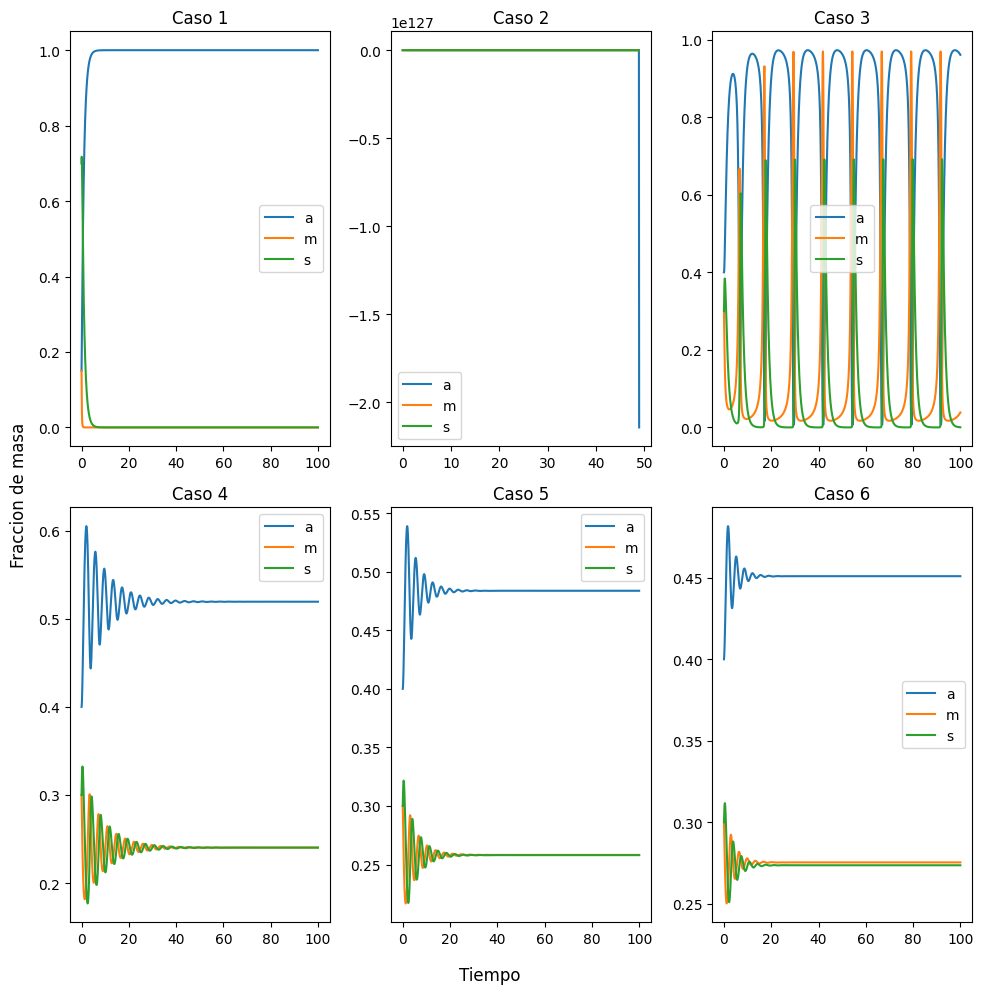

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()

for i, res in enumerate(results):
    a = res['y'][0]
    m = res['y'][1]
    s = 1 - a - m

    axes[i].plot(res['t'], a, label='a')
    axes[i].plot(res['t'], m, label='m')
    axes[i].plot(res['t'], s, label='s')
    axes[i].set_title(f"Caso {i+1}")
    axes[i].legend()

# Source - https://stackoverflow.com/a/65135433
# Posted by Oren, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-28, License - CC BY-SA 4.0
# fuente para fig.supxlabel (...) etc ^ plot loop fue mio

fig.supxlabel('Tiempo')
fig.supylabel('Fraccion de masa')

plt.tight_layout()
plt.show()

2. Grafique en un plano (a(t) , m(t)) las trayectorias en función del tiempo (este plano es llamado plano de fases). Comente qué tipo de comportamiento observa en cada caso? e investigue y describa qué significa la evolución hacia un estado estacionario y la evolución hacia un ciclo límite.

Estos son los graficos que relacionan las trayectorias en funcion del tiempo:

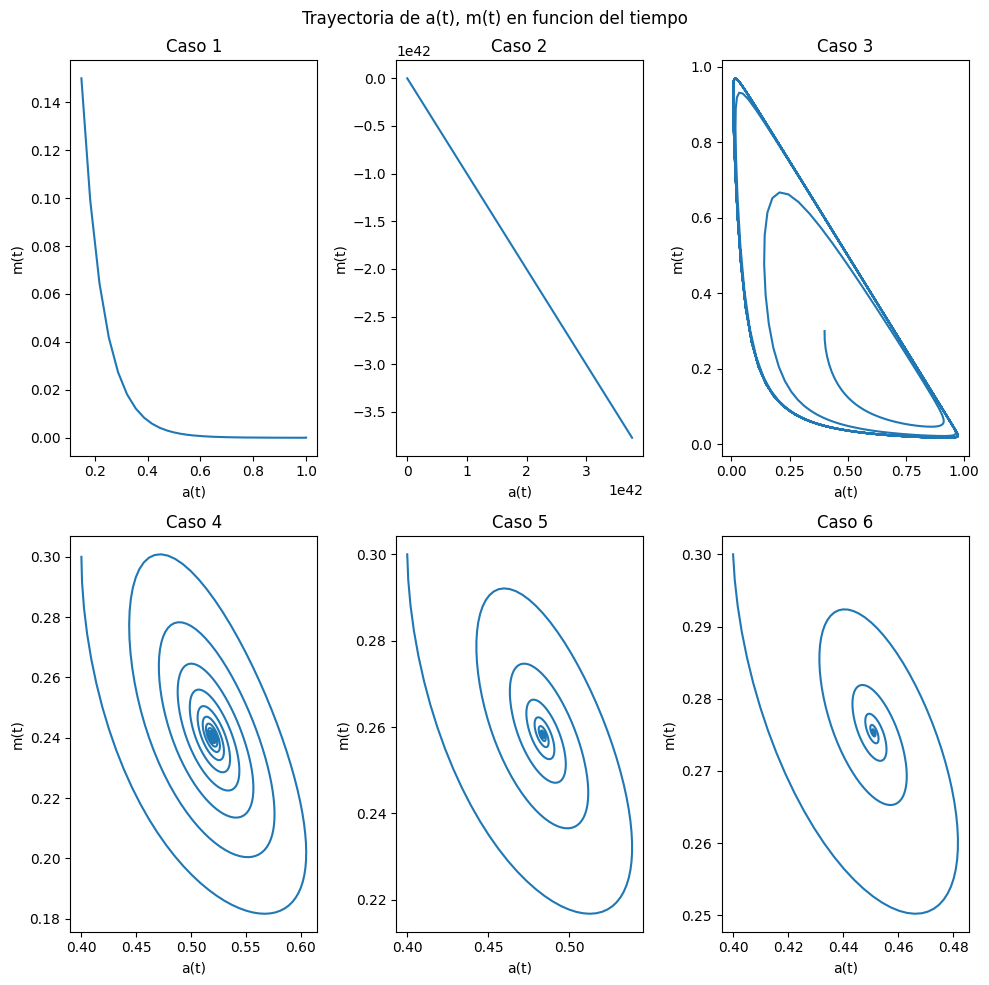

In [144]:
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()

for i, res in enumerate(results):
    a = res['y'][0]
    m = res['y'][1]


    axes[i].plot(a, m)
    axes[i].set_title(f"Caso {i+1}")
    axes[i].set_xlabel('a(t)')
    axes[i].set_ylabel('m(t)')

fig.suptitle("Trayectoria de a(t), m(t) en funcion del tiempo")
fig.tight_layout()

Pero estos no nos dan suficiente informacion sobre COMO van cambiando las derivadas de las funciones en el tiempo. <br>

0 {'a0': 0.15, 'm0': 0.15, 'k1': 10, 'k2': 10, 'alpha': 1.0}
1 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 1.2}
2 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 1.5}
3 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 1.9}
4 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 2.0}
5 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 2.1}


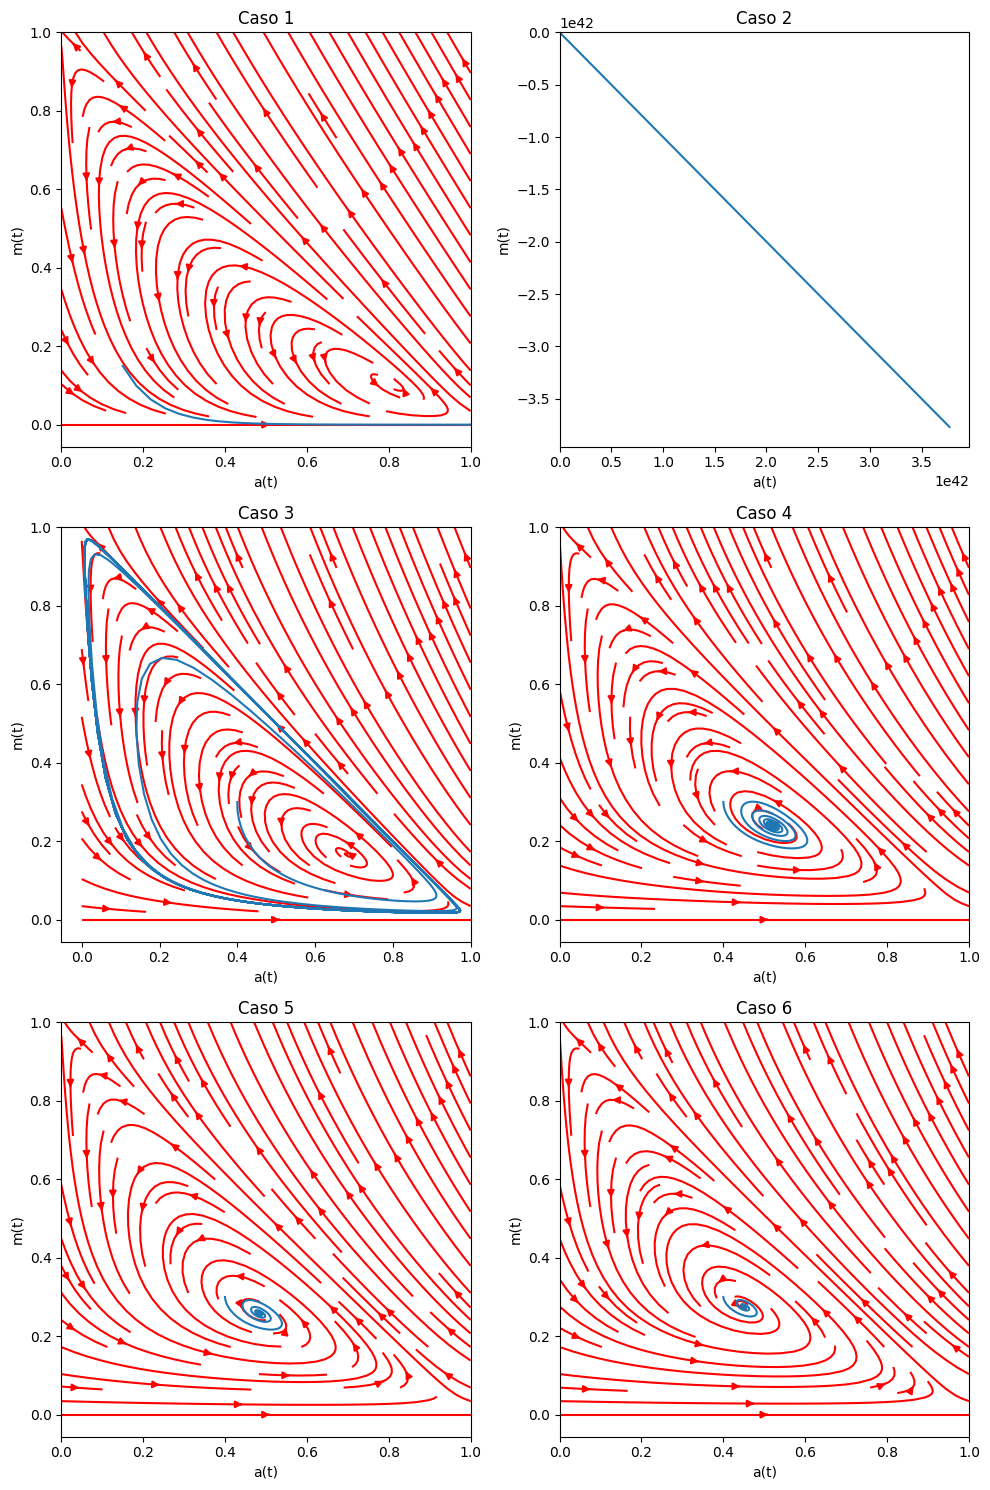

In [ ]:

fig2, axis = plt.subplots(3, 2, figsize=(10, 15))
axisFlatten = axis.flatten()

for idx, case in enumerate(cases):
    ax = axisFlatten[idx]
    print(idx, case)
    k1, k2, alpha, t = case["k1"], case["k2"], case["alpha"], 0

    a_range = np.linspace(0, 1, 20)
    m_range = np.linspace(0, 1, 20)
    A, M = np.meshgrid(a_range, m_range)

    U = np.zeros(A.shape)
    V = np.zeros(M.shape)

    NI, NJ = A.shape 
    for i in range(NI):
        for j in range(NJ):
            current_y = [A[i, j], M[i, j]]

            derivs = objFunc(t, current_y, k1, k2, alpha)
            
            U[i, j] = derivs[0] # dadt
            V[i, j] = derivs[1] # dmdt

    # Evolucion de la derivada
    ax.streamplot(A, M, U, V, color=f'red')

    # Trayectoria c/r al tiempo
    res = results[idx]
    a = res['y'][0]
    m = res['y'][1]
    ax.plot(a, m)
    
    ax.set_title(f"Caso {idx+1}")
    ax.set_xlabel('a(t)')
    ax.set_ylabel('m(t)')


plt.tight_layout()
plt.show()


(escribir conclusiones)